# Fake image detection classifier
- **Classifier labels**: 1 for fake and 0 for real

In [11]:
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

In [12]:
# Constants
DATA_DIR = 'data'
SAVE_PATH = 'preprocessed_data.npz'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE = (64, 64)
IMG_DIR_NAMES = ['wiki', 'inpainting', 'insight', 'text2img']
REAL_IMG_DIR = 'wiki'

In [13]:
# If the image is not from the real dataset, it is fake
# 1: fake, 0: real
def isImgFake(img_main_dir):
    return int(img_main_dir != REAL_IMG_DIR)

In [14]:
# Check if CUDA is available with PyTorch
print("Checking for available hardware...")
print('Using DEVICE:', DEVICE)
if DEVICE.type == 'cuda':
    print(f"CUDA Device: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("No GPU found, using CPU instead")

Checking for available hardware...
Using DEVICE: cuda
CUDA Device: NVIDIA GeForce RTX 4070 Ti SUPER
CUDA Memory: 17.17 GB


In [15]:
# Loading of the images and preprocessing
def load_and_preprocess_images(data_dir, img_size, save_path):
    """
    Loads and preprocesses images from the specified directory.
    Saves the preprocessed data to a file to avoid reprocessing.
    """
    # Check if preprocessed data already exists
    if os.path.exists(save_path):
        print(f"Loading preprocessed data from {save_path}...")
        data = np.load(save_path)
        return data['X'], data['y']
    
    print(f"Loading and preprocessing images from {data_dir}...")
    X = []
    y = []
    
    for index, main_folder in enumerate(IMG_DIR_NAMES):
        main_folder_path = os.path.join(data_dir, main_folder)
        print(f"Processing directory {main_folder}...")
        image_count = 0
        for subfolder_name in os.listdir(main_folder_path):
            subfolder_path = os.path.join(main_folder_path, subfolder_name)
            if os.path.isdir(subfolder_path):
                for filename in os.listdir(subfolder_path):
                    if filename.endswith('.jpg'):
                        img_path = os.path.join(subfolder_path, filename)
                        try:
                            img = Image.open(img_path).convert('RGB')  # Ensure RGB format
                            img = img.resize(img_size)
                            img_array = np.array(img) / 255.0
                            X.append(img_array)
                            y.append(isImgFake(main_folder))  # 1 for other, 0 for wiki
                            image_count += 1
                        except Exception as e:
                            print(f"Error processing {img_path}: {e}")
                    else:
                        print(f"Skipping non jpg file: {filename}")
                        
        print(f"  - Loaded {image_count} images for category {main_folder}")

    print(f"Total images loaded: {len(X)}")
    
    # Convert to numpy arrays
    X = np.array(X)
    y = np.array(y)
    
    print(X)
    print(y)
    
    # Save preprocessed data
    print(f"Saving preprocessed data to {save_path}...")
    np.savez(save_path, X=X, y=y)
    
    return X, y

In [16]:
# Define a simplified CNN
class ComplexCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(ComplexCNN, self).__init__()

        self.features = nn.Sequential(
            # The number of filters (output channels) increases in each subsequent convolutional block (32 -> 64 -> 128 ->256).  This allows the network to learn increasingly complex and abstract features.

            # Block 1: Increase depth, add Batch Norm and Dropout
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),  # Batch Normalization
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.25),  # Dropout

            # Block 2:  Increase depth further, add Batch Norm and Dropout
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.28),

            # Block 3:  Increase depth and complexity, add Batch Norm and Dropout
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.3), # Increased dropout slightly

             # Block 4:  Further Increase Depth
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.32), # Increased dropout slightly
        )

        # Calculate the correct input size for the fully connected layers.
        # With 64x64 input and four 2x2 max pooling operations:
        # 64 / 2 / 2 / 2 / 2 = 4
        self.classifier = nn.Sequential(
            # The classifier part of the network now has two fully connected layers (nn.Linear) instead of one.  
            # This increases the model's capacity to learn non-linear relationships between the features extracted by the convolutional layers and the output classes.  
            # Batch normalization and dropout are also applied to the fully connected layers.
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 1024),  # Increased hidden units
            nn.BatchNorm1d(1024), # Batch Normalization for 1D layers
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),  # Dropout for fully connected layers
            nn.Linear(1024, 512), # Added another fully connected layer
            nn.BatchNorm1d(512),
            nn.ReLU(inplace = True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),  # Output layer
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [17]:
print("\n--- Starting Image Classification ---")

# Load and preprocess data
X, y = load_and_preprocess_images(DATA_DIR, IMG_SIZE, SAVE_PATH)

# Split the data
print("\nSplitting data into training and testing sets (80/20)...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


--- Starting Image Classification ---
Loading preprocessed data from preprocessed_data.npz...

Splitting data into training and testing sets (80/20)...


   image_index  label label_name
0            0      0       Real
1            1      0       Real
2            2      0       Real
3            3      0       Real
4            4      0       Real

Label distribution:
label_name
Fake    90000
Real    30000
Name: count, dtype: int64


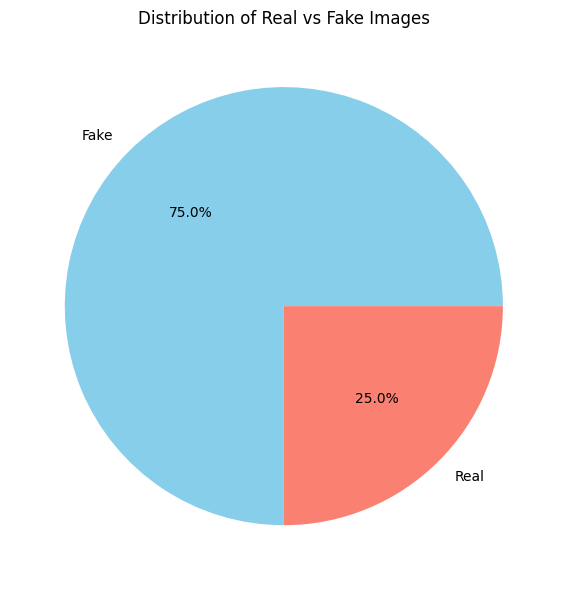

In [18]:
# Create a DataFrame with image indices and their corresponding labels
df_classification = pd.DataFrame({
    'image_index': range(len(y)),
    'label': y
})

# Convert binary labels to descriptive labels
df_classification['label_name'] = df_classification['label'].apply(lambda x: 'Fake' if x == 1 else 'Real')

# Display the first few rows of the DataFrame
print(df_classification.head())

# Display some summary statistics
print("\nLabel distribution:")
print(df_classification['label_name'].value_counts())

# Optional: Create a pie chart visualization of the label distribution
plt.figure(figsize=(8, 6))
df_classification['label_name'].value_counts().plot.pie(autopct='%1.1f%%', colors=['skyblue', 'salmon'])
plt.title('Distribution of Real vs Fake Images')
plt.ylabel('')  # Hide the y-label
plt.tight_layout()
plt.show()

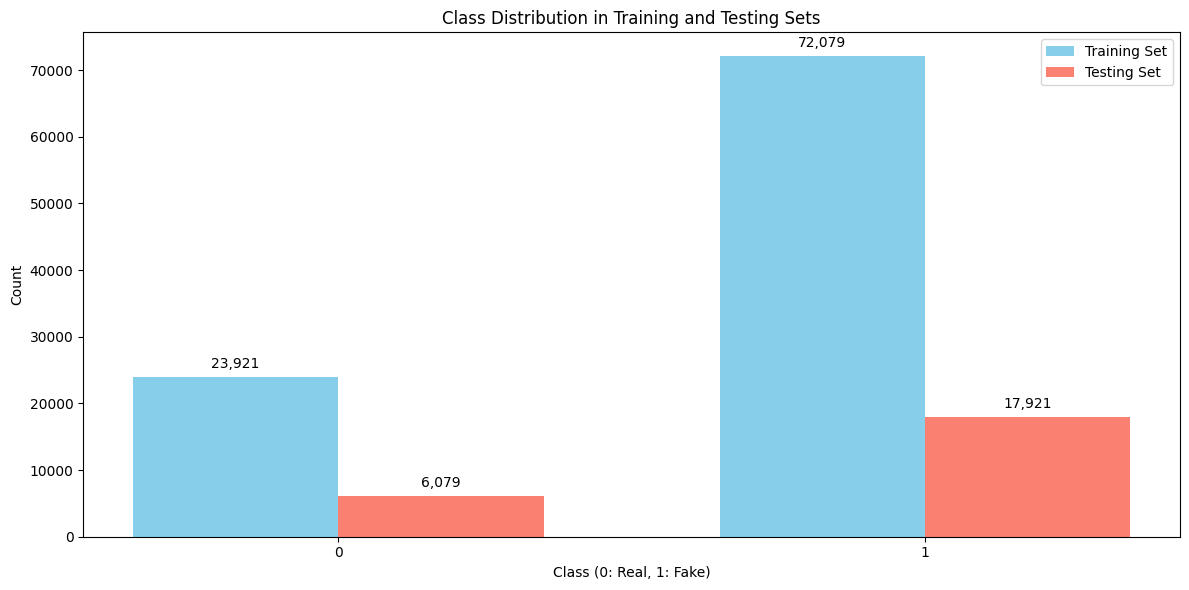

Training set size: 96000 images
Testing set size: 24000 images

Converting data to PyTorch tensors...
Training data shape: torch.Size([96000, 3, 64, 64])


In [19]:
# Visualize class distribution for training and test sets
# Count instances of each class
train_counts = Counter(y_train)
test_counts = Counter(y_test)

# Plot the class distribution
plt.figure(figsize=(12, 6))

# Create a common figure for both distributions
bars1 = plt.bar([0, 1], [train_counts[0], train_counts[1]], width=0.35, label='Training Set', color='skyblue')
bars2 = plt.bar([0.35, 1.35], [test_counts[0], test_counts[1]], width=0.35, label='Testing Set', color='salmon')

# Add labels and title
plt.xlabel('Class (0: Real, 1: Fake)')
plt.ylabel('Count')
plt.title('Class Distribution in Training and Testing Sets')
plt.xticks([0.175, 1.175], ['0', '1'])
plt.legend()

# Add count labels on top of the bars
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1000,
             f'{height:,}', ha='center', va='bottom')
             
for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1000,
             f'{height:,}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print(f"Training set size: {len(X_train)} images")
print(f"Testing set size: {len(X_test)} images")

# Convert to PyTorch tensors with channel-first format
print("\nConverting data to PyTorch tensors...")
X_train = torch.from_numpy(X_train.transpose(0, 3, 1, 2)).float()
X_test = torch.from_numpy(X_test.transpose(0, 3, 1, 2)).float()
y_train = torch.from_numpy(y_train).long()
y_test = torch.from_numpy(y_test).long()
print(f"Training data shape: {X_train.shape}")

In [20]:
from sklearn.metrics import confusion_matrix, classification_report

# Create DataLoaders
batch_size = 32
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

model = ComplexCNN().to(DEVICE)
model = model.to(DEVICE)

# Define loss function for binary classification
criterion = nn.CrossEntropyLoss()
# Use Adam optimizer with weight decay for regularization
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
print(model)

# Training loop
epochs = 5
print("\n--- Starting Training ---")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward pass and optimize
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        # Calculate accuracy
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        if (i+1) % 200 == 0:
            print(f'  Epoch {epoch+1}, Batch {i+1}/{len(train_loader)}, Loss: {loss.item():.4f}')
    
    epoch_acc = 100 * correct / total
    print(f'  Epoch {epoch+1} completed - Accuracy: {epoch_acc:.2f}%')

ComplexCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=

KeyboardInterrupt: 

In [ ]:
# Evaluation
print("\n--- Starting Evaluation ---")
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

with torch.no_grad():
    all_preds = []
    all_labels = []
    
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        outputs = model(inputs)
        print(outputs)
        _, predicted = torch.max(outputs.data, 1)
        
        # Store predictions and labels
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

display(all_labels)
display(all_preds)


# Generate comprehensive reports
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=[0, 1]))

# Plot confusion matrix with sklearn's built-in visualization
cm = confusion_matrix(all_labels, all_preds, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', values_format='.2f')
plt.title('Normalized Confusion Matrix')
plt.savefig('confusion_matrix.png')
plt.show()

print("\n--- Classification Complete ---")


--- Starting Evaluation ---
tensor([[-0.3792,  0.4126],
        [-0.3449,  0.3905],
        [-0.4530,  0.5128],
        [-0.4369,  0.4749],
        [-0.5276,  0.5656],
        [-2.9832,  2.8521],
        [-0.6119,  0.6429],
        [-0.4828,  0.5151],
        [-0.5036,  0.5495],
        [-5.0561,  4.7831],
        [-0.3271,  0.3802],
        [-0.2913,  0.3466],
        [-3.4964,  3.3166],
        [-0.2669,  0.2991],
        [-0.4420,  0.4851],
        [-0.2444,  0.2895],
        [-0.2900,  0.3389],
        [-0.3359,  0.3817],
        [-0.2961,  0.3313],
        [-0.3068,  0.3527],
        [-1.3448,  1.3120],
        [-0.2300,  0.2791],
        [-0.3085,  0.3471],
        [-1.6575,  1.5965],
        [-0.3506,  0.3889],
        [-0.4061,  0.4630],
        [-0.2514,  0.2941],
        [-2.3538,  2.2568],
        [-0.3014,  0.3448],
        [-0.2090,  0.2435],
        [-2.8660,  2.7216],
        [-0.4432,  0.4742]], device='cuda:0')
tensor([[-3.5806,  3.4027],
        [-0.3154,  0.3638],
 

[1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 1,


[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,



--- Classification Complete ---
